# Missing Value Diagnostics

This notebook provides a strict audit of **when** missing values occur and **which columns** are affected in the final feature table.

It also includes a root-cause investigation layer to classify missingness into likely causes:
- point-in-time lag warmup
- rolling/statistical warmup
- target horizon truncation (`h1..h72`)
- inherited source gaps
- pipeline-introduced gaps


In [69]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-paper')
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)


## 1) Load Datasets

- `df_features`: final model input dataset
- `df_refined`: pre-feature engineering reference to detect inherited vs introduced missingness


In [70]:
FEATURE_PATH_CANDIDATES = [
    '../data/features/all_data_features.parquet',
]
REFINED_PATH = '../data/processed/all_data_refined.parquet'

feature_path = next((p for p in FEATURE_PATH_CANDIDATES if Path(p).exists()), None)
if feature_path is None:
    raise FileNotFoundError(f'No feature parquet found in: {FEATURE_PATH_CANDIDATES}')

if not Path(REFINED_PATH).exists():
    raise FileNotFoundError(f'Missing refined parquet: {REFINED_PATH}')

print('Using feature file:', feature_path)
print('Using refined file:', REFINED_PATH)

df_features = pl.read_parquet(feature_path).to_pandas()
df_refined = pl.read_parquet(REFINED_PATH).to_pandas()

for name, df in [('features', df_features), ('refined', df_refined)]:
    if 'timestamp_utc' not in df.columns:
        raise KeyError(f"{name}: missing 'timestamp_utc' column")
    df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'], utc=True, errors='coerce')
    df.sort_values('timestamp_utc', inplace=True)
    df.set_index('timestamp_utc', inplace=True)

print('features shape:', df_features.shape)
print('refined shape :', df_refined.shape)
print('time range    :', df_features.index.min(), '->', df_features.index.max())


Using feature file: ../data/features/all_data_features.parquet
Using refined file: ../data/processed/all_data_refined.parquet
features shape: (879, 337)
refined shape : (44568, 109)
time range    : 2023-12-31 23:00:00+00:00 -> 2024-02-06 13:00:00+00:00


## 2) Global Overview: Which Columns Have Missing Values?

In [71]:
missing_count = df_features.isna().sum().sort_values(ascending=False)
missing_pct = (missing_count / len(df_features) * 100).round(4)

missing_overview = pd.DataFrame({
    'missing_count': missing_count,
    'missing_pct': missing_pct,
})

missing_overview_nonzero = missing_overview[missing_overview['missing_count'] > 0]

print(f"Columns total: {df_features.shape[1]}")
print(f"Columns with >=1 NaN: {len(missing_overview_nonzero)}")
print(f"Columns with 0 NaN: {df_features.shape[1] - len(missing_overview_nonzero)}")

missing_overview_nonzero.head(50)


Columns total: 337
Columns with >=1 NaN: 0
Columns with 0 NaN: 337


,missing_count,missing_pct


In [72]:
# Bar plot of top missing columns
show_n = min(40, len(missing_overview_nonzero))
if show_n > 0:
    top_missing = missing_overview_nonzero.head(show_n).iloc[::-1]
    fig, ax = plt.subplots(figsize=(12, max(6, show_n * 0.25)))
    ax.barh(top_missing.index, top_missing['missing_pct'])
    ax.set_xlabel('Missing [%]')
    ax.set_title(f'Top {show_n} Columns by Missing Percentage')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values in features dataset.')


No missing values in features dataset.


## 3) When Do Missing Values Occur? (Timeline)

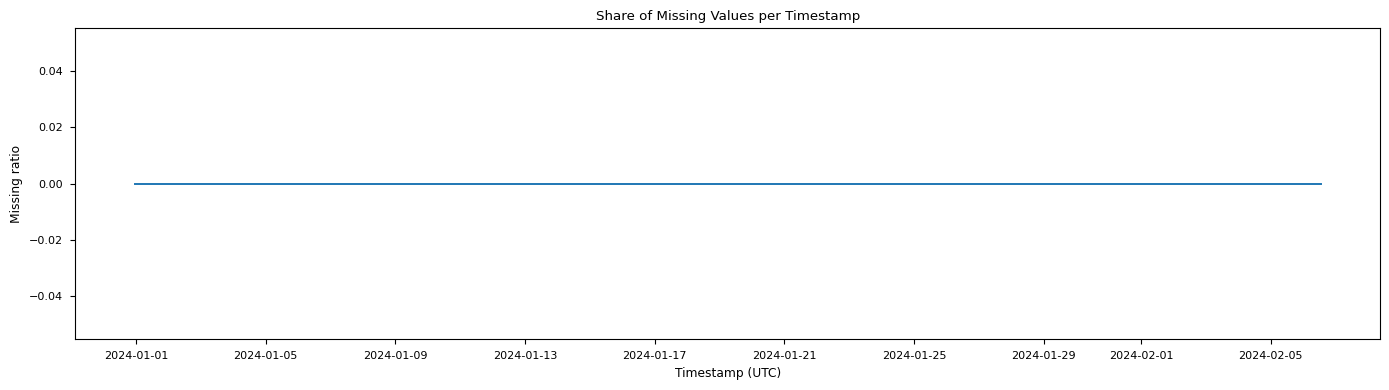

count    879.0
mean       0.0
std        0.0
min        0.0
50%        0.0
90%        0.0
95%        0.0
99%        0.0
max        0.0
dtype: float64

In [73]:
missing_per_ts = df_features.isna().sum(axis=1)
missing_rate_per_ts = missing_per_ts / df_features.shape[1]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(missing_rate_per_ts.index, missing_rate_per_ts.values)
ax.set_title('Share of Missing Values per Timestamp')
ax.set_ylabel('Missing ratio')
ax.set_xlabel('Timestamp (UTC)')
plt.tight_layout()
plt.show()

missing_per_ts.describe(percentiles=[0.5, 0.9, 0.95, 0.99])


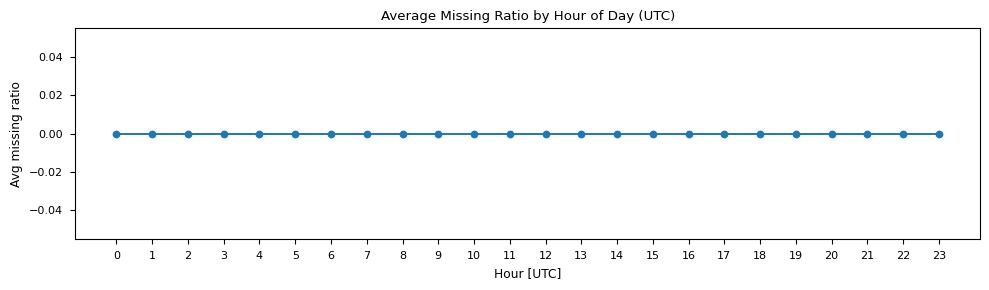

,avg_missing_ratio
timestamp_utc,
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
5,0.0
6,0.0
7,0.0
8,0.0


In [74]:
# Which hours-of-day are most affected?
missing_by_hour = missing_rate_per_ts.groupby(missing_rate_per_ts.index.hour).mean()

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(missing_by_hour.index, missing_by_hour.values, marker='o')
ax.set_xticks(range(24))
ax.set_title('Average Missing Ratio by Hour of Day (UTC)')
ax.set_xlabel('Hour [UTC]')
ax.set_ylabel('Avg missing ratio')
plt.tight_layout()
plt.show()

missing_by_hour.to_frame('avg_missing_ratio')


## 4) Matrix View: Which Columns Are Missing at Which Times?

In [75]:
# To keep rendering fast, show only top missing columns
matrix_cols = missing_overview_nonzero.head(50).index.tolist()

if matrix_cols:
    miss_matrix = df_features[matrix_cols].isna().astype(int).T
    # Downsample rows if too long
    max_points = 1200
    if miss_matrix.shape[1] > max_points:
        step = int(np.ceil(miss_matrix.shape[1] / max_points))
        miss_matrix = miss_matrix.iloc[:, ::step]

    plt.figure(figsize=(16, max(6, len(matrix_cols) * 0.18)))
    sns.heatmap(miss_matrix, cmap='Reds', cbar=True)
    plt.title('Missingness Matrix (1 = Missing, 0 = Present)')
    plt.xlabel('Time (downsampled)')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
else:
    print('No missing columns to visualize.')


No missing columns to visualize.


## 5) Root-Cause Diagnostics per Column

This block computes whether NaNs are at the **beginning**, **end**, or **inside** the series and infers likely causes.


In [76]:
from pathlib import Path

def _leading_true_run(mask: pd.Series) -> int:
    arr = mask.to_numpy()
    if len(arr) == 0:
        return 0
    first_false = np.argmax(~arr)
    if first_false == 0 and arr[0]:
        return len(arr) if arr.all() else 0
    if arr.all():
        return len(arr)
    return int(first_false)


def _trailing_true_run(mask: pd.Series) -> int:
    arr = mask.to_numpy()
    if len(arr) == 0:
        return 0
    rev = arr[::-1]
    first_false = np.argmax(~rev)
    if first_false == 0 and rev[0]:
        return len(arr) if arr.all() else 0
    if rev.all():
        return len(arr)
    return int(first_false)


def _max_internal_gap(mask: pd.Series, leading: int, trailing: int) -> int:
    arr = mask.to_numpy().astype(int)
    n = len(arr)
    if n == 0:
        return 0
    left = leading
    right = n - trailing
    if right <= left:
        return 0
    core = arr[left:right]
    max_gap = 0
    cur = 0
    for v in core:
        if v == 1:
            cur += 1
            max_gap = max(max_gap, cur)
        else:
            cur = 0
    return int(max_gap)


def _infer_cause(col: str, lead: int, trail: int, internal: int, pct: float, introduced_only: bool) -> str:
    c = col.lower()

    if re.match(r'^target_(pos|neg)_h\d+$', c):
        return 'Target horizon truncation at tail due to shift(-h)'

    if any(k in c for k in ['_lag24', '_lag48', '_lag168']) or c.endswith('_lag'):
        return 'Engineered lag feature warmup at head'

    if any(k in c for k in ['rolling', '_std_', '_mean_', '_zscore_', '_ewma']):
        return 'Rolling/statistical warmup window introduces head NaNs'

    if any(k in c for k in ['_actual_entsoe', 'nrv_balance', 'afrr_activated', 'mfrr_activated', 'picasso', 'intraday']):
        return 'PiT lag layer or source latency (head NaNs expected)'

    if 'forecast_da' in c:
        if internal > 0:
            return 'Publication gating / persistence fallback + source gaps'
        return 'Forecast publication timing or sparse source coverage'

    if c.startswith('da_price_'):
        if pct == 0:
            return 'Strict T-0 synchronous feature (expected complete)'
        return 'Unexpected for DA price; check ingestion alignment'

    if introduced_only:
        return 'Introduced during feature engineering (transformation-generated)'

    if internal > 0:
        return 'Inherited source gap(s) inside series'

    if lead > 0 and trail == 0:
        return 'Head-only warmup (lag/rolling initialization)'

    if trail > 0 and lead == 0:
        return 'Tail-only truncation (future-shift target/horizon feature)'

    return 'Mixed pattern; requires manual column-level review'


feature_missing = df_features.isna().sum()
refined_common_cols = [c for c in df_features.columns if c in df_refined.columns]

rows = []
for col in df_features.columns:
    s = df_features[col]
    m = s.isna()
    total = int(m.sum())
    if total == 0:
        continue

    lead = _leading_true_run(m)
    trail = _trailing_true_run(m)
    internal = max(0, total - lead - trail)
    max_gap = _max_internal_gap(m, lead, trail)

    first_ts = s.index[m.argmax()] if total > 0 else pd.NaT
    last_ts = s.index[len(m) - 1 - m.iloc[::-1].argmax()] if total > 0 else pd.NaT

    refined_missing = int(df_refined[col].isna().sum()) if col in df_refined.columns else np.nan
    introduced_only = False
    inherited_vs_introduced = np.nan
    if col in df_refined.columns:
        added_mask = df_features[col].isna() & (~df_refined[col].isna())
        inherited_mask = df_features[col].isna() & (df_refined[col].isna())
        introduced = int(added_mask.sum())
        inherited = int(inherited_mask.sum())
        introduced_only = introduced > 0 and inherited == 0
        inherited_vs_introduced = f'inherited={inherited}, introduced={introduced}'

    pct = total / len(df_features) * 100
    cause = _infer_cause(col, lead, trail, internal, pct, introduced_only)

    rows.append({
        'column': col,
        'missing_count': total,
        'missing_pct': pct,
        'leading_nan_run_h': lead,
        'trailing_nan_run_h': trail,
        'internal_nan_count': internal,
        'max_internal_gap_h': max_gap,
        'first_missing_ts': first_ts,
        'last_missing_ts': last_ts,
        'refined_missing_count': refined_missing,
        'inherited_vs_introduced': inherited_vs_introduced,
        'likely_cause': cause,
    })

expected_cols = [
    'column', 'missing_count', 'missing_pct', 'leading_nan_run_h', 'trailing_nan_run_h',
    'internal_nan_count', 'max_internal_gap_h', 'first_missing_ts', 'last_missing_ts',
    'refined_missing_count', 'inherited_vs_introduced', 'likely_cause',
]

df_causes = pd.DataFrame(rows)
if df_causes.empty:
    df_causes = pd.DataFrame(columns=expected_cols)
else:
    for c in expected_cols:
        if c not in df_causes.columns:
            df_causes[c] = np.nan
    df_causes = df_causes[expected_cols].sort_values(['missing_pct', 'column'], ascending=[False, True])

print('Columns diagnosed:', len(df_causes))

df_causes.head(60)


KeyError: 'missing_pct'

In [ ]:
# Cause summary
if not df_causes.empty:
    cause_summary = (
        df_causes.groupby('likely_cause', dropna=False)
        .agg(
            columns=('column', 'count'),
            avg_missing_pct=('missing_pct', 'mean'),
            total_missing=('missing_count', 'sum'),
        )
        .sort_values('columns', ascending=False)
    )
    cause_summary
else:
    print('No missing-value causes to summarize.')


## 6) Deep-Dive: Columns with Unexpected Internal Gaps

In [ ]:
suspect = df_causes[
    (df_causes['internal_nan_count'] > 0) &
    (~df_causes['likely_cause'].str.contains('Target horizon', case=False, na=False))
].copy()

suspect[['column', 'missing_pct', 'internal_nan_count', 'max_internal_gap_h', 'likely_cause']].head(40)


,column,missing_pct,internal_nan_count,max_internal_gap_h,likely_cause
0,da_price_eur_log1p,0.796359,7,5,Unexpected for DA price; check ingestion align...
1,price_intraday_eur_log1p,0.796359,7,5,PiT lag layer or source latency (head NaNs exp...


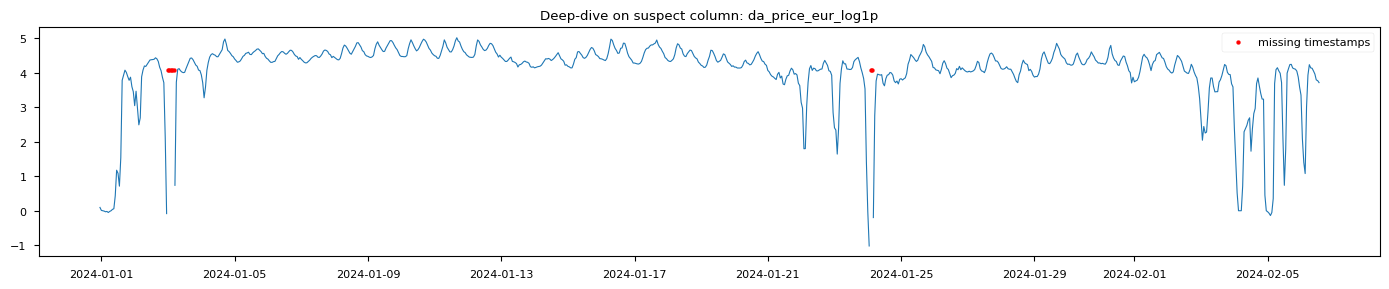

In [ ]:
# Visualize first suspect column (if any)
if not suspect.empty:
    col = suspect.iloc[0]['column']
    s = df_features[col]
    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(s.index, s.values, lw=0.8)
    miss_idx = s[s.isna()].index
    if len(miss_idx) > 0:
        ax.scatter(miss_idx, [np.nanmean(s.values)] * len(miss_idx), color='red', s=8, label='missing timestamps')
    ax.set_title(f'Deep-dive on suspect column: {col}')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
else:
    print('No suspect internal-gap columns detected.')


## 7) Export Audit Tables

Use these exports in your thesis appendix and QA workflow.


In [ ]:
out_dir = Path('data/processed')
out_dir.mkdir(parents=True, exist_ok=True)

out_overview = out_dir / 'missing_overview_features.csv'
out_causes = out_dir / 'missing_root_cause_diagnostics.csv'

missing_overview_nonzero.to_csv(out_overview)
df_causes.to_csv(out_causes, index=False)

print('Saved:')
print('-', out_overview)
print('-', out_causes)


Saved:
- data/processed/missing_overview_features.csv
- data/processed/missing_root_cause_diagnostics.csv


## 8) Interpretation Checklist

Use this checklist to decide whether missingness is acceptable:

1. **Head-only NaNs** in lag/rolling features are expected warmup effects.
2. **Tail-only NaNs** in `target_*_h*` are expected due to forward target shifts.
3. **Internal NaNs** in raw physical columns indicate source outages or ingestion gaps and should be investigated.
4. **Unexpected NaNs in strict T-0 features** (e.g., `da_price_*`) indicate alignment/gating issues.


## 9) Structural Gap Forensic Mapping

This section maps **continuous NaN runs** for selected market columns and focuses on
**structural gaps** (>2 hours).

Target columns:
- `price_intraday_eur_log1p`
- `da_price_eur_log1p`
- `da_price_BE`
- `wind_onshore_error_id`


In [ ]:
TARGET_COLS = [
    'price_intraday_eur_log1p',
    'da_price_eur_log1p',
    'da_price_BE',
    'wind_onshore_error_id',
]

missing_targets = [c for c in TARGET_COLS if c not in df_features.columns]
if missing_targets:
    print('Missing target columns in df_features:', missing_targets)

cols_present = [c for c in TARGET_COLS if c in df_features.columns]
print('Columns analyzed:', cols_present)


Columns analyzed: ['price_intraday_eur_log1p', 'da_price_eur_log1p', 'da_price_BE', 'wind_onshore_error_id']


In [ ]:
import numpy as np
import pandas as pd


def detect_nan_runs(series: pd.Series, ts_index: pd.DatetimeIndex, col_name: str) -> pd.DataFrame:
    mask = series.isna().to_numpy(dtype=bool)
    idx = np.flatnonzero(mask)
    if len(idx) == 0:
        return pd.DataFrame(columns=['column', 'start_ts', 'end_ts', 'duration_h'])

    runs = []
    start = idx[0]
    prev = idx[0]
    for i in idx[1:]:
        if i == prev + 1:
            prev = i
        else:
            runs.append((start, prev))
            start = i
            prev = i
    runs.append((start, prev))

    out = []
    for s, e in runs:
        duration = int(e - s + 1)
        out.append(
            {
                'column': col_name,
                'start_ts': ts_index[s],
                'end_ts': ts_index[e],
                'duration_h': duration,
            }
        )
    return pd.DataFrame(out)


all_runs = []
for c in cols_present:
    all_runs.append(detect_nan_runs(df_features[c], df_features.index, c))

gap_runs = pd.concat(all_runs, ignore_index=True) if all_runs else pd.DataFrame(
    columns=['column', 'start_ts', 'end_ts', 'duration_h']
)

print('Total NaN runs detected:', len(gap_runs))
gap_runs.head(20)


Total NaN runs detected: 4


,column,start_ts,end_ts,duration_h
0,price_intraday_eur_log1p,2024-01-03 01:00:00+00:00,2024-01-03 05:00:00+00:00,5
1,price_intraday_eur_log1p,2024-01-24 03:00:00+00:00,2024-01-24 04:00:00+00:00,2
2,da_price_eur_log1p,2024-01-03 00:00:00+00:00,2024-01-03 04:00:00+00:00,5
3,da_price_eur_log1p,2024-01-24 02:00:00+00:00,2024-01-24 03:00:00+00:00,2


In [ ]:
# Filter: structural gaps only (>2h)
structural_runs = gap_runs[gap_runs['duration_h'] > 2].copy()
structural_runs = structural_runs.sort_values(['duration_h', 'start_ts'], ascending=[False, True])

print('Structural runs (>2h):', len(structural_runs))
structural_runs


Structural runs (>2h): 2


,column,start_ts,end_ts,duration_h
2,da_price_eur_log1p,2024-01-03 00:00:00+00:00,2024-01-03 04:00:00+00:00,5
0,price_intraday_eur_log1p,2024-01-03 01:00:00+00:00,2024-01-03 05:00:00+00:00,5


In [ ]:
# Overlap analysis: largest gap overlap between DA and intraday log prices

def largest_gap(df: pd.DataFrame, col: str):
    d = df[df['column'] == col]
    if d.empty:
        return None
    d = d.sort_values(['duration_h', 'start_ts'], ascending=[False, True])
    return d.iloc[0]

lg_da = largest_gap(structural_runs, 'da_price_eur_log1p')
lg_id = largest_gap(structural_runs, 'price_intraday_eur_log1p')

if lg_da is None or lg_id is None:
    print('Could not compute overlap: one or both largest gaps are missing.')
else:
    overlap_start = max(lg_da['start_ts'], lg_id['start_ts'])
    overlap_end = min(lg_da['end_ts'], lg_id['end_ts'])
    has_overlap = overlap_start <= overlap_end

    print('Largest da_price_eur_log1p gap:')
    print(f"  start={lg_da['start_ts']} end={lg_da['end_ts']} duration_h={int(lg_da['duration_h'])}")
    print('Largest price_intraday_eur_log1p gap:')
    print(f"  start={lg_id['start_ts']} end={lg_id['end_ts']} duration_h={int(lg_id['duration_h'])}")
    print('Overlap exists:', bool(has_overlap))

    if has_overlap:
        overlap_h = int((overlap_end - overlap_start) / pd.Timedelta(hours=1)) + 1
        print(f'Overlap window: {overlap_start} -> {overlap_end} ({overlap_h}h)')


Largest da_price_eur_log1p gap:
  start=2024-01-03 00:00:00+00:00 end=2024-01-03 04:00:00+00:00 duration_h=5
Largest price_intraday_eur_log1p gap:
  start=2024-01-03 01:00:00+00:00 end=2024-01-03 05:00:00+00:00 duration_h=5
Overlap exists: True
Overlap window: 2024-01-03 01:00:00+00:00 -> 2024-01-03 04:00:00+00:00 (4h)


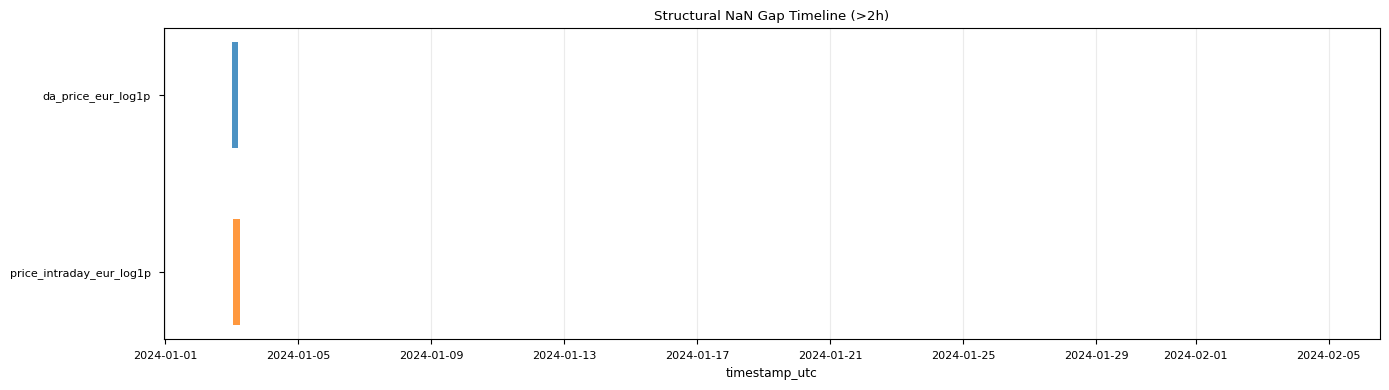

In [ ]:
import matplotlib.pyplot as plt

plot_df = structural_runs.copy()
if plot_df.empty:
    print('No structural gaps (>2h) to plot.')
else:
    col_order = [c for c in TARGET_COLS if c in plot_df['column'].unique()]
    y_map = {c: i for i, c in enumerate(col_order)}

    fig, ax = plt.subplots(figsize=(14, max(4, len(col_order) * 1.1)))

    for _, r in plot_df.iterrows():
        y = y_map[r['column']]
        left = r['start_ts']
        width = r['end_ts'] - r['start_ts'] + pd.Timedelta(hours=1)
        ax.barh(y=y, width=width, left=left, height=0.6, alpha=0.8)

    ax.set_yticks(list(y_map.values()))
    ax.set_yticklabels(list(y_map.keys()))
    ax.set_title('Structural NaN Gap Timeline (>2h)')
    ax.set_xlabel('timestamp_utc')
    ax.grid(axis='x', alpha=0.25)

    # Show full dataset range context
    ax.set_xlim(df_features.index.min(), df_features.index.max())

    plt.tight_layout()
    plt.show()
